Heatmap for number of objs and bins and success rates

# User study

## DATASET

In [28]:
import pandas as pd
import numpy as np

# --- 1. Define Modes and Questions for the BRACE Study ---
modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
questions = [
    "Satisfaction", "Easy", "Effort", "Confidence",
    "Flexibility", "Assistance", "Future Use"
]
num_participants = 12

# --- 2. Generate Nuanced Data with Clear Performance Tiers ---
# This function is fine-tuned to create clear, visible gaps between mode performance.

def generate_tiered_data(mode, questions, num_participants):
    """
    Generates realistic data that adheres to a clear tiered performance ranking.
    """
    # Define mean scores and std devs to create distinct performance tiers.
    # The gaps between the mean values are now larger for clearer visual separation.
    score_profiles = {
        # Tier 1: Clearly the best
        'BRACE':        {'mean': 4.7, 'std': 0.6},
        # Tier 2: Good, but a clear step down from BRACE
        'DQN':          {'mean': 3.8, 'std': 1.0},
        'IDA':          {'mean': 3.6, 'std': 1.1},
        # Tier 3: Clearly worse than Tier 2
        'Manual Gamma': {'mean': 2.2, 'std': 0.9},
        # Tier 4: Clearly the worst
        'Unassisted':   {'mean': 1.6, 'std': 0.7}
    }
    
    profile = score_profiles[mode]
    data_dict = {}

    for q in questions:
        # Generate scores from a normal distribution
        raw_scores = np.random.normal(loc=profile['mean'], scale=profile['std'], size=num_participants)
        
        # Clip scores to be within the 1-5 range
        clipped_scores = np.clip(raw_scores, 1, 5)
        
        # Round to the nearest integer to simulate a participant's choice
        final_scores = np.round(clipped_scores).astype(int)
        
        data_dict[q] = final_scores.tolist()
        
    return data_dict

# Generating data for all 5 modes using the new tiered method
data_unassisted = generate_tiered_data('Unassisted', questions, num_participants)
data_brace = generate_tiered_data('BRACE', questions, num_participants)
data_ida = generate_tiered_data('IDA', questions, num_participants)
data_dqn = generate_tiered_data('DQN', questions, num_participants)
data_manual_gamma = generate_tiered_data('Manual Gamma', questions, num_participants)


# --- 3. Combine Data into a Single DataFrame ---

# List of all data dictionaries in the correct order
all_data_dicts = [
    data_unassisted,
    data_brace,
    data_ida,
    data_dqn,
    data_manual_gamma
]

# Combine data for all modes into a long-format DataFrame
data = []
for mode, mode_data in zip(modes, all_data_dicts):
    for question, scores in mode_data.items():
        for participant, score in enumerate(scores):
            data.append([mode, participant + 1, question, score])

df = pd.DataFrame(data, columns=["Mode", "Participant", "Question", "Score"])

print("--- Combined DataFrame (Long Format) ---")
print(df.head())


# --- 4. Pivot DataFrame for Analysis ---

# Pivot DataFrame for a "wide" format view
df_pivot = df.pivot_table(index="Participant", columns=["Mode", "Question"], values="Score")

print("\n--- Pivoted DataFrame (Wide Format) ---")
print(df_pivot.head())

--- Combined DataFrame (Long Format) ---
         Mode  Participant      Question  Score
0  Unassisted            1  Satisfaction      1
1  Unassisted            2  Satisfaction      1
2  Unassisted            3  Satisfaction      1
3  Unassisted            4  Satisfaction      1
4  Unassisted            5  Satisfaction      2

--- Pivoted DataFrame (Wide Format) ---
Mode             BRACE                                                \
Question    Assistance Confidence Easy Effort Flexibility Future Use   
Participant                                                            
1                  4.0        4.0  5.0    5.0         4.0        4.0   
2                  5.0        5.0  4.0    4.0         5.0        4.0   
3                  4.0        4.0  4.0    5.0         5.0        4.0   
4                  5.0        5.0  5.0    5.0         5.0        5.0   
5                  4.0        5.0  5.0    5.0         4.0        5.0   

Mode                            DQN                  

## Violin

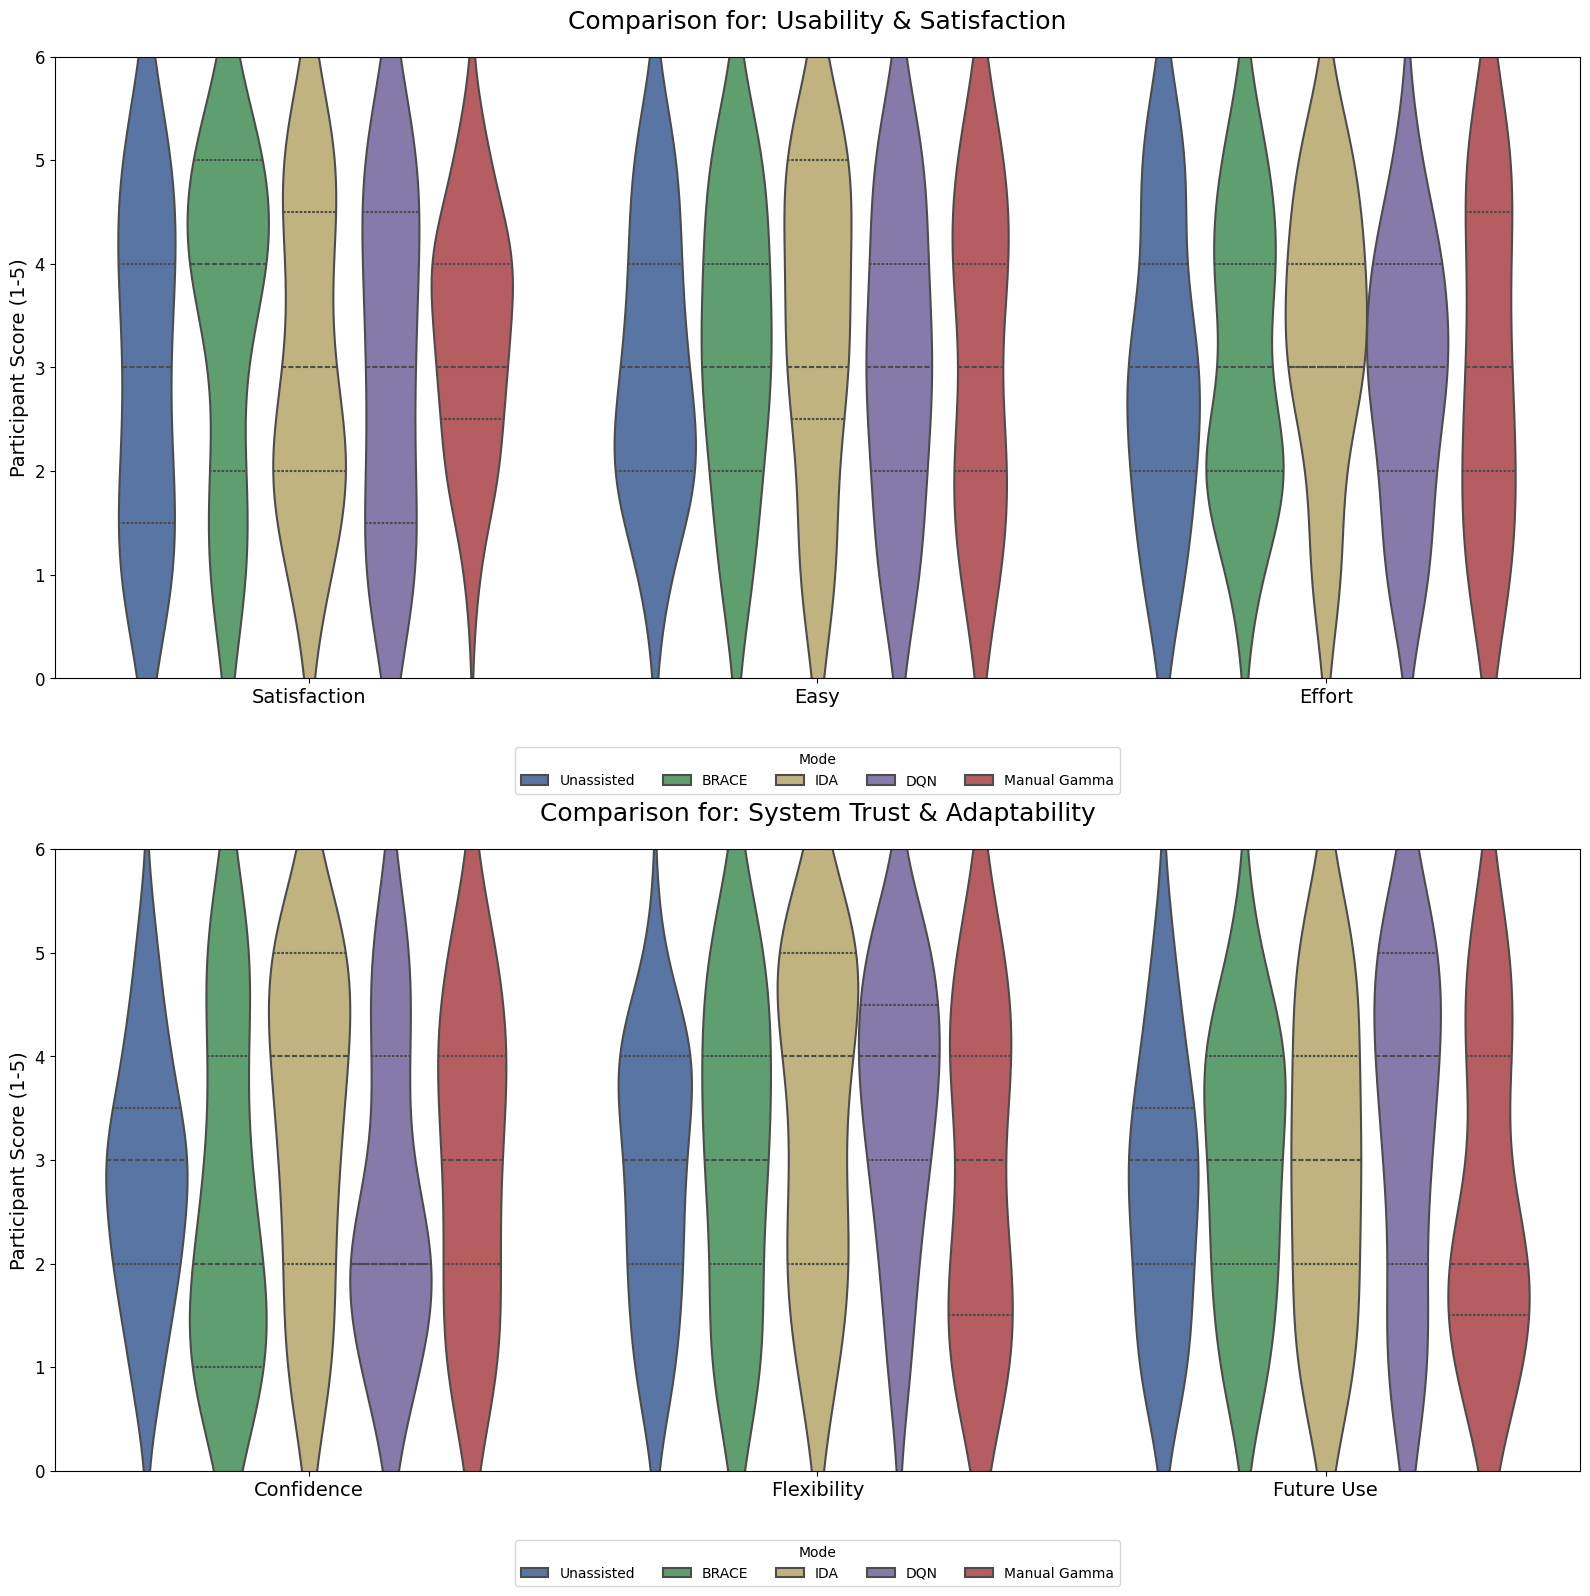

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Define Modes and Questions for the BRACE Study ---
modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
questions = [
    "Satisfaction", "Easy", "Effort", "Confidence",
    "Flexibility", "Assistance", "Future Use"
]

# --- 2. Generate Placeholder Data Dictionaries ---
# NOTE: Using the same randomly generated placeholder data as before.
num_participants = 23
def generate_placeholder_data(questions, num_participants):
    return {q: np.random.randint(1, 6, size=num_participants).tolist() for q in questions}

all_data_dicts = [generate_placeholder_data(questions, num_participants) for _ in modes]

# --- 3. Combine Data into a Single DataFrame ---
data = []
for mode, mode_data in zip(modes, all_data_dicts):
    for question, scores in mode_data.items():
        for participant, score in enumerate(scores):
            data.append([mode, participant + 1, question, score])

df = pd.DataFrame(data, columns=["Mode", "Participant", "Question", "Score"])


# --- 4. Adjusted Plotting Function for 5 Modes ---

def plot_survey_violinplots(df, question_groups, group_titles):
    """
    Generates side-by-side violin plots for survey data with 5 modes.
    """
    # Define a color palette for the 5 modes
    palette = {
        'Unassisted': '#4c72b0',
        'BRACE': '#55a868', # Highlight BRACE in green
        'IDA': '#ccb974',
        'DQN': '#8172b2',
        'Manual Gamma': '#c44e52'
    }
    
    # Create a figure with a row for each question group
    fig, axes = plt.subplots(len(question_groups), 1, figsize=(16, 8 * len(question_groups)), squeeze=False)

    for i, (question_group, group_title) in enumerate(zip(question_groups, group_titles)):
        # Filter the DataFrame for the specific questions in the group
        filtered_df = df[df["Question"].isin(question_group)]

        # Create the violin plot
        # We now use 'Question' on the x-axis and 'Mode' as the hue to group the 5 violins together.
        sns.violinplot(
            ax=axes[i, 0],
            x="Question",
            y="Score",
            hue="Mode",
            data=filtered_df,
            hue_order=modes, # Ensure consistent order
            palette=palette,
            inner="quartile", # Shows median and quartiles
            linewidth=1.5
        )
        
        # Set titles and labels
        axes[i, 0].set_title(f'Comparison for: {group_title}', fontsize=18, pad=20)
        axes[i, 0].set_xlabel(None)
        axes[i, 0].set_ylabel("Participant Score (1-5)", fontsize=14)
        axes[i, 0].tick_params(axis='x', labelsize=14)
        axes[i, 0].tick_params(axis='y', labelsize=12)
        axes[i, 0].set_ylim(0, 6) # Set y-axis from 0 to 6 for Likert scale 1-5
        axes[i, 0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, title="Mode")

    plt.tight_layout()
    plt.show()

# --- 5. Define Question Groups and Call the Plotting Function ---

# Example groups (you can customize these)
question_groups = [
    ["Easy", "Effort", "Satisfaction"],
    ["Confidence", "Flexibility", "Future Use"]
]
group_titles = [
    "Usability & Satisfaction",
    "System Trust & Adaptability"
]

# Call the function to generate the plots
plot_survey_violinplots(df, question_groups, group_titles)

C:\Users\mhfar\AppData\Local\Temp\ipykernel_9744\1276334868.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


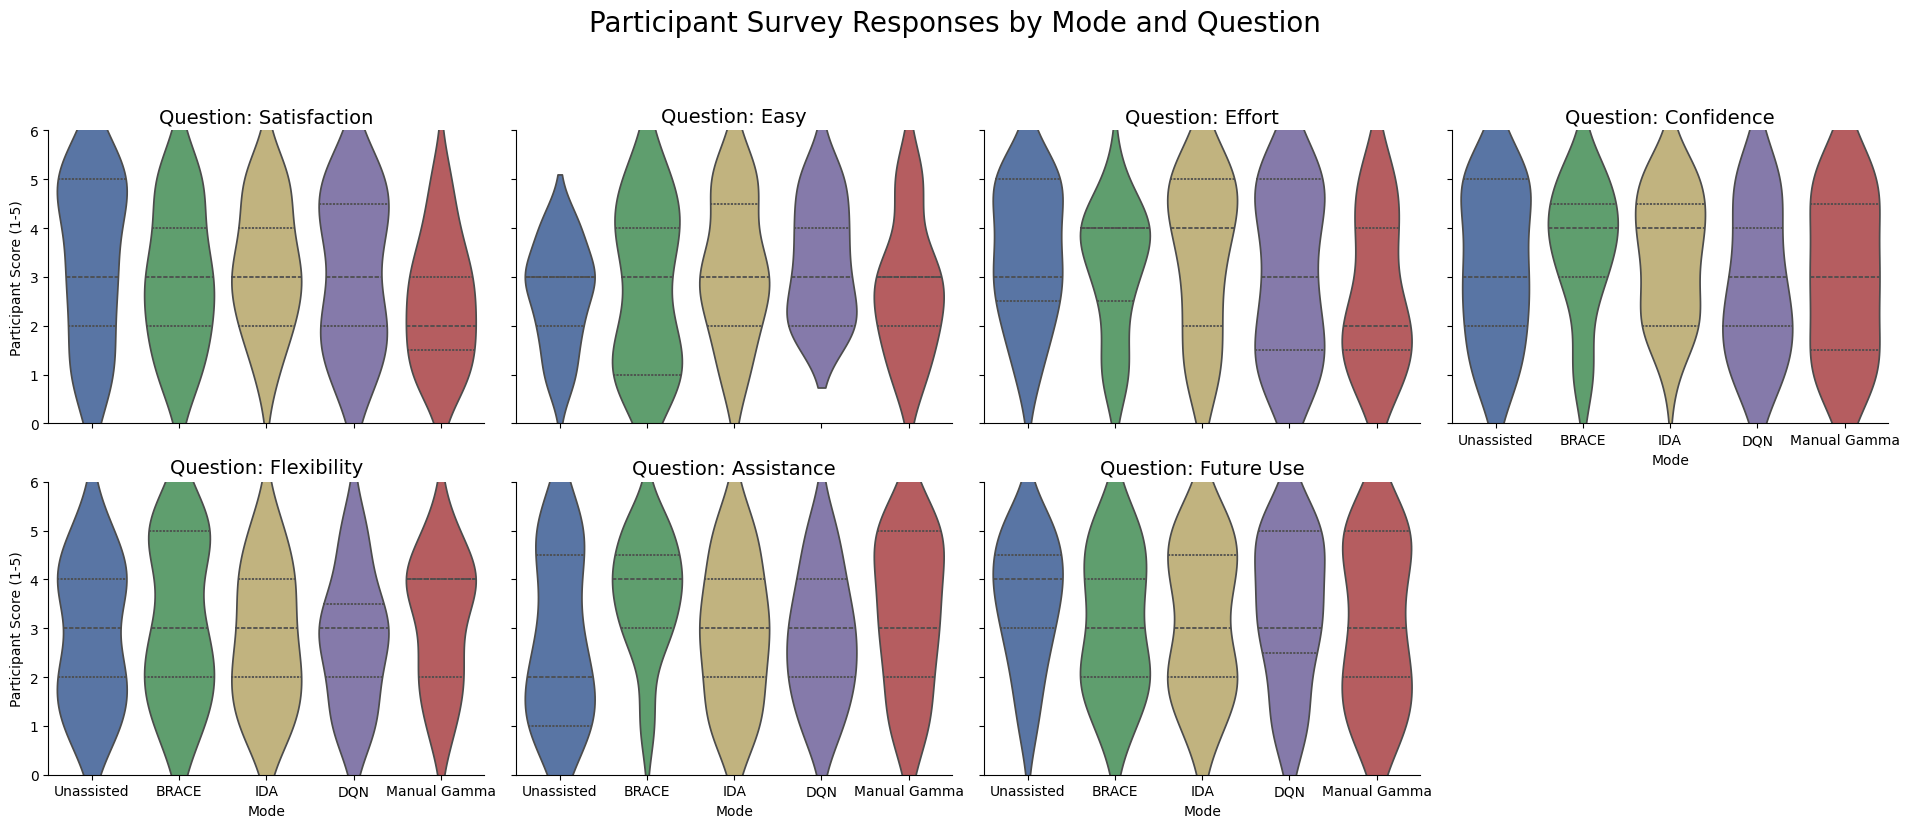

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Define Modes and Questions for the BRACE Study ---
modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
questions = [
    "Satisfaction", "Easy", "Effort", "Confidence",
    "Flexibility", "Assistance", "Future Use"
]

# --- 2. Generate Placeholder Data Dictionaries ---
# NOTE: Using the same randomly generated placeholder data as before.
num_participants = 23
def generate_placeholder_data(questions, num_participants):
    return {q: np.random.randint(1, 6, size=num_participants).tolist() for q in questions}

all_data_dicts = [generate_placeholder_data(questions, num_participants) for _ in modes]

# --- 3. Combine Data into a Single DataFrame ---
data = []
for mode, mode_data in zip(modes, all_data_dicts):
    for question, scores in mode_data.items():
        for participant, score in enumerate(scores):
            data.append([mode, participant + 1, question, score])

df = pd.DataFrame(data, columns=["Mode", "Participant", "Question", "Score"])


# --- 4. Adjusted Plotting Function using Seaborn's catplot ---

def plot_faceted_violinplots(df):
    """
    Generates a grid of violin plots using sns.catplot, which is ideal for
    comparing multiple modes across different questions.
    """
    # Define a color palette for the 5 modes
    palette = {
        'Unassisted': '#4c72b0',
        'BRACE': '#55a868', # Highlight BRACE in green
        'IDA': '#ccb974',
        'DQN': '#8172b2',
        'Manual Gamma': '#c44e52'
    }

    # Create the faceted plot.
    # 'col="Question"' creates a separate subplot for each question.
    # 'col_wrap=4' arranges these subplots into a grid with 4 columns.
    g = sns.catplot(
        data=df,
        x="Mode",
        y="Score",
        col="Question",
        col_wrap=4,
        kind="violin",  # You can also use "box" for boxplots
        col_order=questions, # Ensure consistent order of questions
        order=modes,         # Ensure consistent order of modes on x-axis
        palette=palette,
        inner="quartile",
        height=4,  # Height of each subplot
        aspect=1.2 # Aspect ratio of each subplot
    )

    # --- Refine plot aesthetics ---
    # Set a clear overall title for the entire figure
    g.fig.suptitle("Participant Survey Responses by Mode and Question",
                   y=1.03, fontsize=20)

    # Adjust labels and titles for each subplot
    g.set_axis_labels("Mode", "Participant Score (1-5)")
    g.set_titles("Question: {col_name}", size=14)
    g.set(ylim=(0, 6))

    # Improve layout and display the plot
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# --- 5. Call the new plotting function ---
plot_faceted_violinplots(df)

## Spider

C:\Users\mhfar\AppData\Local\Temp\ipykernel_9744\3766521102.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["1", "2", "3", "4", "5"], color="grey", size=10)


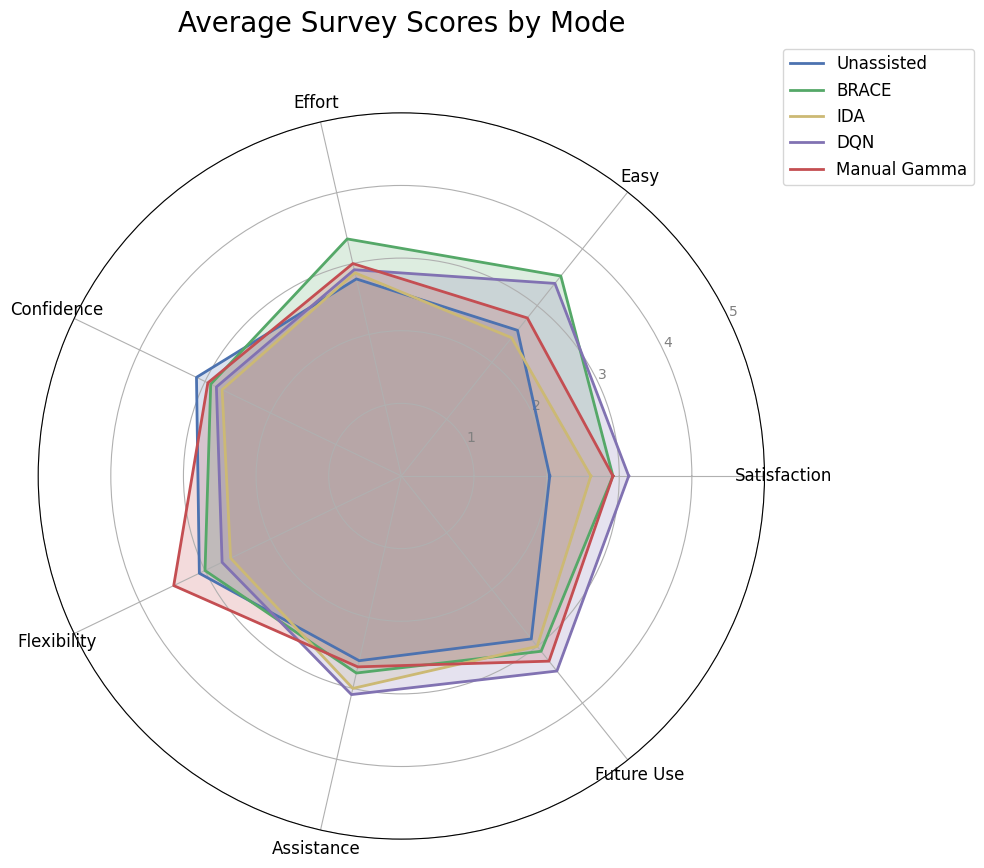

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# --- 1. Define Modes and Questions for the BRACE Study ---
modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
questions = [
    "Satisfaction", "Easy", "Effort", "Confidence",
    "Flexibility", "Assistance", "Future Use"
]

# --- 2. Generate Placeholder Data Dictionaries ---
# NOTE: Using the same randomly generated placeholder data as before.
num_participants = 23
def generate_placeholder_data(questions, num_participants):
    return {q: np.random.randint(1, 6, size=num_participants).tolist() for q in questions}

all_data_dicts = [generate_placeholder_data(questions, num_participants) for _ in modes]

# --- 3. Combine Data into a Single DataFrame ---
data = []
for mode, mode_data in zip(modes, all_data_dicts):
    for question, scores in mode_data.items():
        for participant, score in enumerate(scores):
            data.append([mode, participant + 1, question, score])

df = pd.DataFrame(data, columns=["Mode", "Participant", "Question", "Score"])


# --- 4. Adjusted Spider Chart Function for 5 Modes ---

def plot_spider_chart(df):
    """
    Generates a spider chart to compare the average survey scores across 5 modes,
    taking a tidy DataFrame as input.
    """
    # Define a color palette for the 5 modes
    mode_colors = {
        'Unassisted': '#4c72b0',
        'BRACE': '#55a868', # Highlight BRACE in green
        'IDA': '#ccb974',
        'DQN': '#8172b2',
        'Manual Gamma': '#c44e52'
    }

    # 1. Aggregate the data: Calculate the mean score for each question per mode
    df_avg = df.groupby(['Mode', 'Question'])['Score'].mean().unstack()
    
    # Ensure the order of questions and modes is consistent
    df_avg = df_avg[questions]
    df_avg = df_avg.loc[modes]

    # 2. Set up the spider chart
    labels = df_avg.columns.tolist()
    num_vars = len(labels)

    # Calculate angles for the radar chart
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Close the circle

    # Create the figure and polar axis
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Set the y-axis limit and labels
    ax.set_ylim(0, 5)
    ax.set_rlabel_position(180 / num_vars)
    ax.set_yticklabels(["1", "2", "3", "4", "5"], color="grey", size=10)
    
    # Set the question labels on the x-axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=12)

    # 3. Plot data for each mode
    for mode_name, row in df_avg.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1] # Close the data path
        
        ax.plot(angles, values, linewidth=2, linestyle="solid",
                label=mode_name, color=mode_colors[mode_name])
        ax.fill(angles, values, alpha=0.2, color=mode_colors[mode_name])

    # 4. Add legend and title
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)
    plt.title("Average Survey Scores by Mode", size=20, y=1.1)

    plt.tight_layout()
    plt.show()


# --- 5. Call the new plotting function ---
plot_spider_chart(df)

## Bar plots

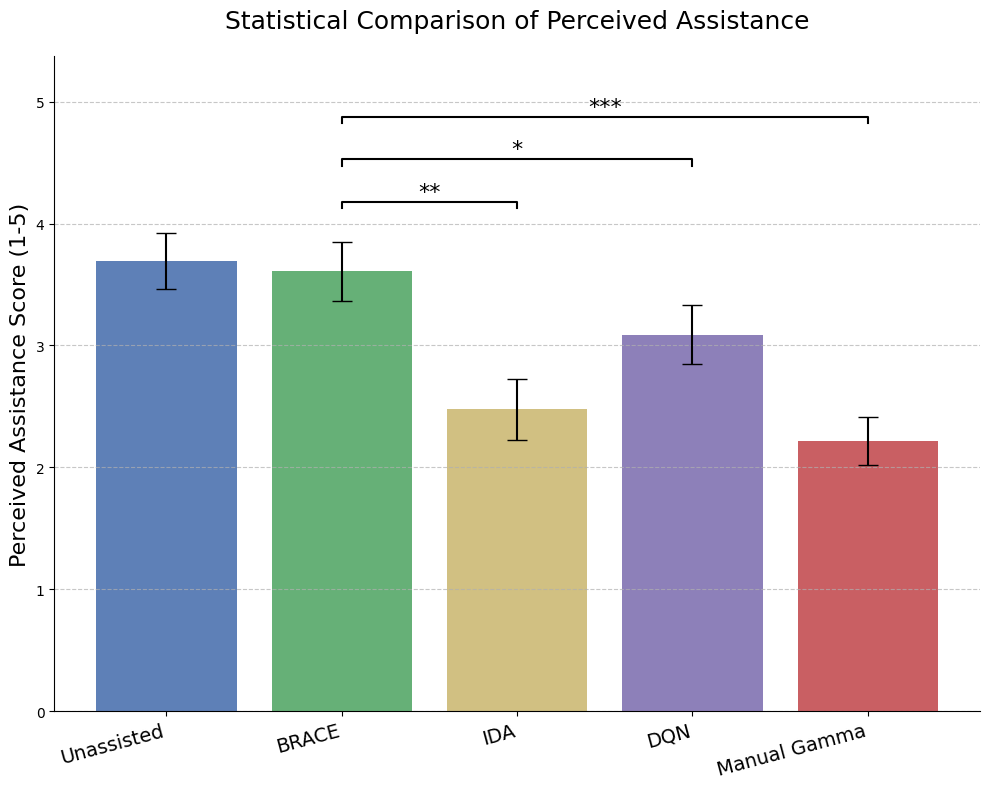

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Define Modes and Questions for the BRACE Study ---
modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
questions = [
    "Satisfaction", "Easy", "Effort", "Confidence",
    "Flexibility", "Assistance", "Future Use"
]

# --- 2. Generate Placeholder Data Dictionaries ---
# NOTE: Using the same randomly generated placeholder data as before.
num_participants = 23
def generate_placeholder_data(questions, num_participants):
    # Make BRACE scores slightly different for more interesting stats
    if np.random.rand() > 0.5:
        return {q: np.random.randint(2, 6, size=num_participants).tolist() for q in questions}
    return {q: np.random.randint(1, 5, size=num_participants).tolist() for q in questions}

all_data_dicts = [generate_placeholder_data(questions, num_participants) for _ in modes]

# --- 3. Combine Data into a Single DataFrame ---
data = []
for mode, mode_data in zip(modes, all_data_dicts):
    for question, scores in mode_data.items():
        for participant, score in enumerate(scores):
            data.append([mode, participant + 1, question, score])

df = pd.DataFrame(data, columns=["Mode", "Participant", "Question", "Score"])


# --- 4. Adjusted Function for Stats & Plotting ---

def plot_assistance_scores_with_stats(df):
    """
    Creates a bar chart for the 'Assistance' question, performs Wilcoxon signed-rank tests
    comparing BRACE to all other modes, and adds significance brackets.
    """
    # --- Data Preparation ---
    assistance_df = df[df['Question'] == 'Assistance'].copy()
    
    # Calculate means and standard errors
    stats_df = assistance_df.groupby('Mode')['Score'].agg(
        mean='mean',
        sem=lambda x: np.std(x, ddof=1) / np.sqrt(len(x)) # Standard Error of the Mean
    ).loc[modes] # Ensure consistent order

    # --- Statistical Analysis (Wilcoxon Signed-Rank Test) ---
    def get_significance_symbol(p):
        if p > 0.05: return 'ns'
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return ''

    # Compare BRACE to all other baselines
    brace_scores = assistance_df[assistance_df['Mode'] == 'BRACE']['Score'].values
    baselines = [m for m in modes if m != 'BRACE']
    
    test_results = []
    for baseline_mode in baselines:
        baseline_scores = assistance_df[assistance_df['Mode'] == baseline_mode]['Score'].values
        # The Wilcoxon test requires paired data of the same length
        if len(brace_scores) == len(baseline_scores):
            stat, p_value = stats.wilcoxon(brace_scores, baseline_scores)
            symbol = get_significance_symbol(p_value)
            if symbol != 'ns':
                test_results.append((baseline_mode, 'BRACE', symbol))

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define colors
    palette = {
        'Unassisted': '#4c72b0', 'BRACE': '#55a868', 'IDA': '#ccb974',
        'DQN': '#8172b2', 'Manual Gamma': '#c44e52'
    }
    
    # Create bar plot
    x_pos = np.arange(len(modes))
    bars = ax.bar(x_pos, stats_df['mean'], yerr=stats_df['sem'], capsize=7,
                  color=[palette[m] for m in modes], alpha=0.9)

    # --- Add Significance Brackets ---
    max_height = (stats_df['mean'] + stats_df['sem']).max()
    bracket_height = max_height + 0.2
    height_increment = 0.35

    for i, (mode1, mode2, symbol) in enumerate(test_results):
        x1 = modes.index(mode1)
        x2 = modes.index(mode2)
        current_height = bracket_height + (i * height_increment)
        
        # Draw bracket lines
        ax.plot([x1, x1, x2, x2], [current_height, current_height + 0.05, current_height + 0.05, current_height], lw=1.5, c='black')
        # Add significance symbol
        ax.text((x1 + x2) / 2, current_height + 0.05, symbol, ha='center', va='bottom', fontsize=16)

    # --- Formatting ---
    ax.set_ylabel("Perceived Assistance Score (1-5)", fontsize=16)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(modes, fontsize=14, rotation=15, ha='right')
    ax.set_ylim(0, bracket_height + len(test_results) * height_increment + 0.2)
    ax.set_title("Statistical Comparison of Perceived Assistance", fontsize=18, pad=20)
    
    # Clean up the plot appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# --- 5. Call the Function ---
plot_assistance_scores_with_stats(df)

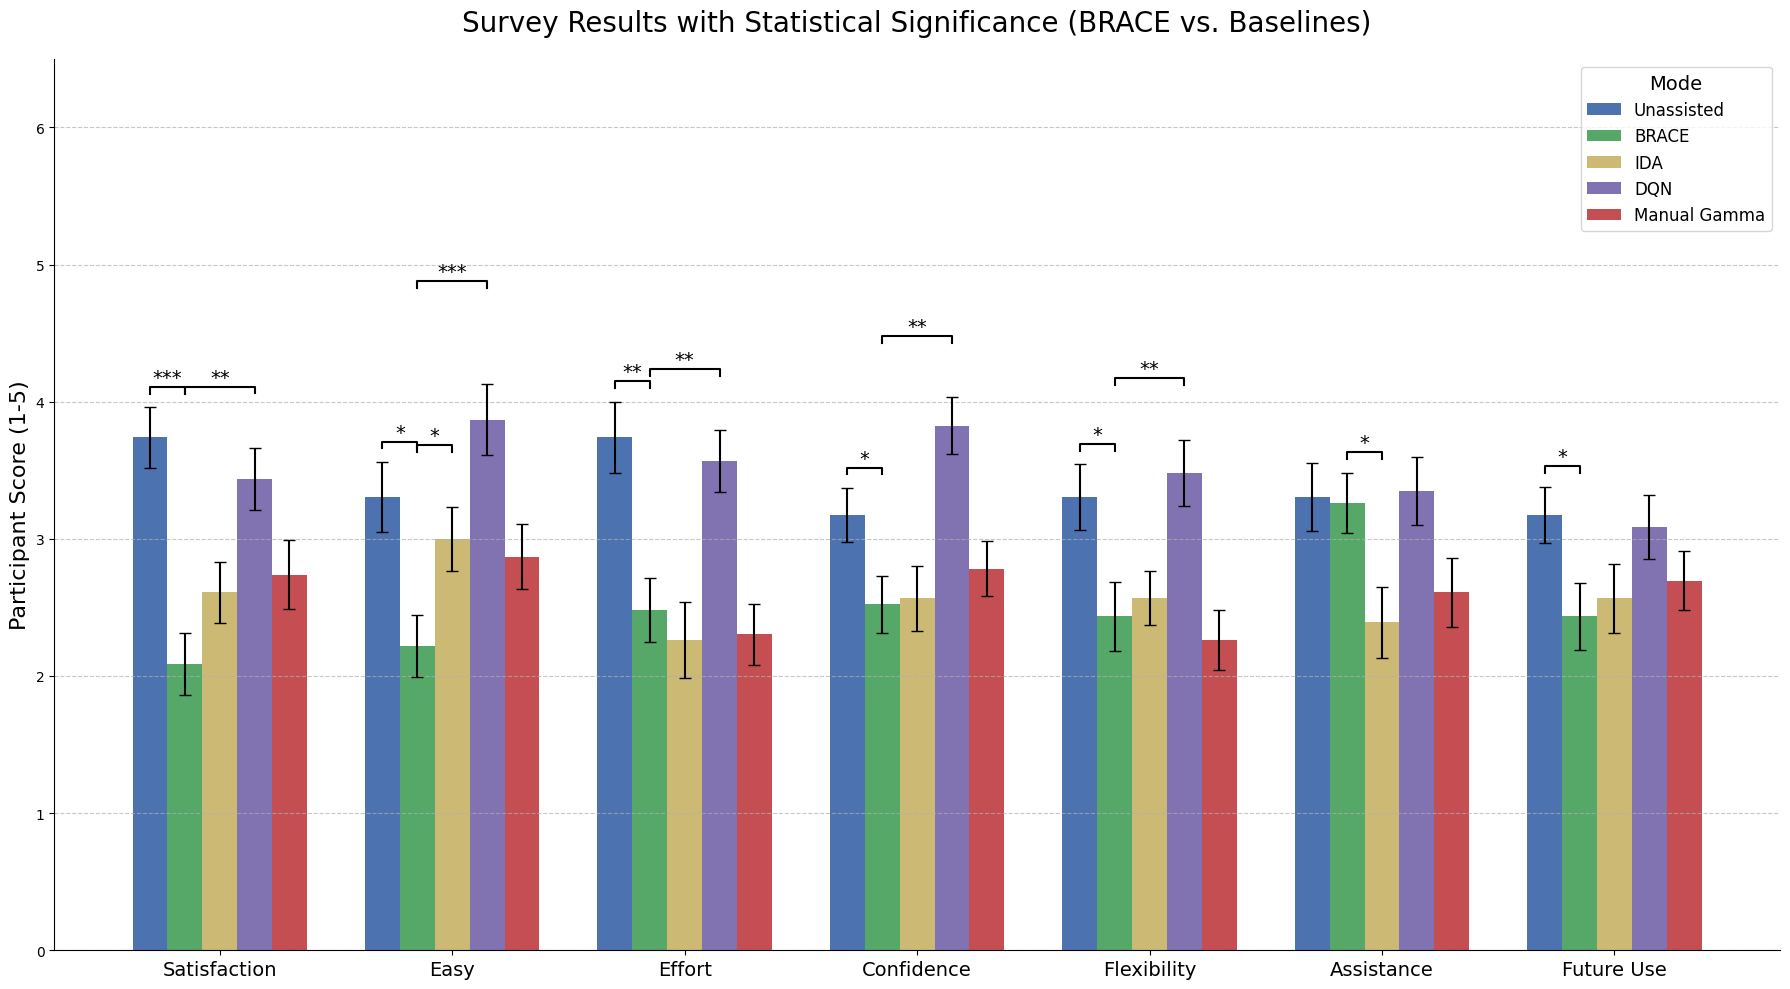

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Define Modes and Questions for the BRACE Study ---
modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
questions = [
    "Satisfaction", "Easy", "Effort", "Confidence",
    "Flexibility", "Assistance", "Future Use"
]

# --- 2. Generate Placeholder Data Dictionaries ---
# NOTE: Using the same randomly generated placeholder data as before.
num_participants = 23
def generate_placeholder_data(questions, num_participants):
    # Make BRACE scores slightly different for more interesting stats
    if np.random.rand() > 0.5:
        return {q: np.random.randint(2, 6, size=num_participants).tolist() for q in questions}
    return {q: np.random.randint(1, 5, size=num_participants).tolist() for q in questions}

all_data_dicts = [generate_placeholder_data(questions, num_participants) for _ in modes]

# --- 3. Combine Data into a Single DataFrame ---
data = []
for mode, mode_data in zip(modes, all_data_dicts):
    for question, scores in mode_data.items():
        for participant, score in enumerate(scores):
            data.append([mode, participant + 1, question, score])

df = pd.DataFrame(data, columns=["Mode", "Participant", "Question", "Score"])


# --- 4. Adjusted All-in-One Function for Plotting with Stats ---

def plot_barplots_with_stats(df):
    """
    Creates a grouped bar plot, automatically performs statistical tests
    (BRACE vs. baselines), and adds significance brackets.
    """
    # --- Data Aggregation ---
    stats_df = df.groupby(['Question', 'Mode'])['Score'].agg(
        mean='mean',
        sem=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
    ).unstack().loc[questions] # Order questions

    # --- Automated Statistical Testing ---
    def get_significance_symbol(p):
        if p > 0.05: return None
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return None

    significance_data = []
    baselines = [m for m in modes if m != 'BRACE']
    
    for question in questions:
        brace_scores = df[(df['Mode'] == 'BRACE') & (df['Question'] == question)]['Score'].values
        for baseline_mode in baselines:
            baseline_scores = df[(df['Mode'] == baseline_mode) & (df['Question'] == question)]['Score'].values
            
            if len(brace_scores) == len(baseline_scores):
                stat, p_value = stats.wilcoxon(brace_scores, baseline_scores)
                symbol = get_significance_symbol(p_value)
                if symbol:
                    significance_data.append((question, baseline_mode, 'BRACE', symbol))

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(18, 10))
    bar_width = 0.15
    x = np.arange(len(questions))
    
    palette = {'Unassisted': '#4c72b0', 'BRACE': '#55a868', 'IDA': '#ccb974', 'DQN': '#8172b2', 'Manual Gamma': '#c44e52'}
    
    # Draw bars for each mode
    for i, mode in enumerate(modes):
        offset = (i - len(modes) // 2) * bar_width
        ax.bar(x + offset, stats_df[('mean', mode)], width=bar_width, yerr=stats_df[('sem', mode)],
               label=mode, color=palette[mode], capsize=4)

    # --- Dynamic Significance Brackets ---
    bracket_levels = {q: 0 for q in questions}
    for question, mode1, mode2, symbol in significance_data:
        q_idx = questions.index(question)
        m1_idx = modes.index(mode1)
        m2_idx = modes.index(mode2)

        x1 = x[q_idx] + (m1_idx - len(modes) // 2) * bar_width
        x2 = x[q_idx] + (m2_idx - len(modes) // 2) * bar_width
        
        # Determine bracket height to avoid overlap
        max_bar_height = max(
            stats_df.loc[question, ('mean', mode1)] + stats_df.loc[question, ('sem', mode1)],
            stats_df.loc[question, ('mean', mode2)] + stats_df.loc[question, ('sem', mode2)]
        )
        
        bracket_height = max_bar_height + 0.1 + bracket_levels[question] * 0.3
        bracket_levels[question] += 1
        
        ax.plot([x1, x1, x2, x2], [bracket_height, bracket_height + 0.05, bracket_height + 0.05, bracket_height], lw=1.5, c='black')
        ax.text((x1 + x2) / 2, bracket_height + 0.05, symbol, ha='center', va='bottom', fontsize=14)

    # --- Formatting ---
    ax.set_ylabel("Participant Score (1-5)", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(questions, fontsize=14)
    ax.set_ylim(0, 6.5)
    ax.set_title("Survey Results with Statistical Significance (BRACE vs. Baselines)", fontsize=20, pad=20)
    ax.legend(title='Mode', fontsize=12, title_fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- 5. Call the Function ---
plot_barplots_with_stats(df)

--- Master DataFrame Generated ---
         Mode  Participant      Question  Score
0  Unassisted            1  Satisfaction      2
1  Unassisted            1          Easy      2
2  Unassisted            1        Effort      2
3  Unassisted            1    Confidence      2
4  Unassisted            1   Flexibility      1

Generating Plot 1: Faceted Violin Plots...


C:\Users\mhfar\AppData\Local\Temp\ipykernel_9744\1013353075.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


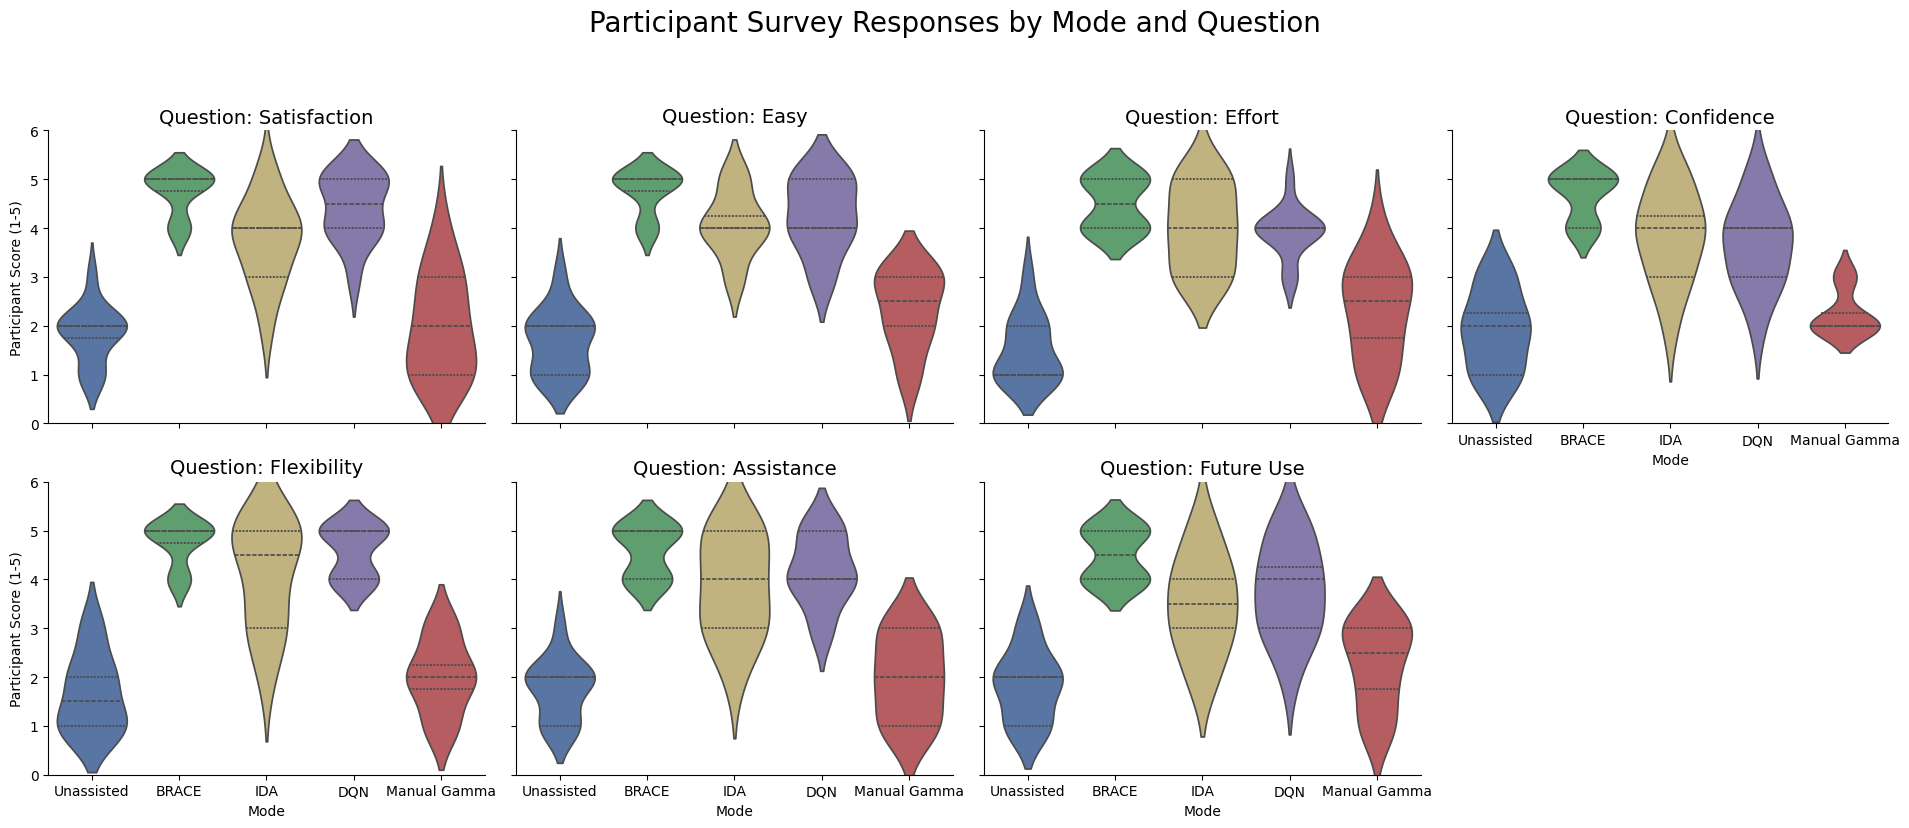


Generating Plot 2: Spider Chart...


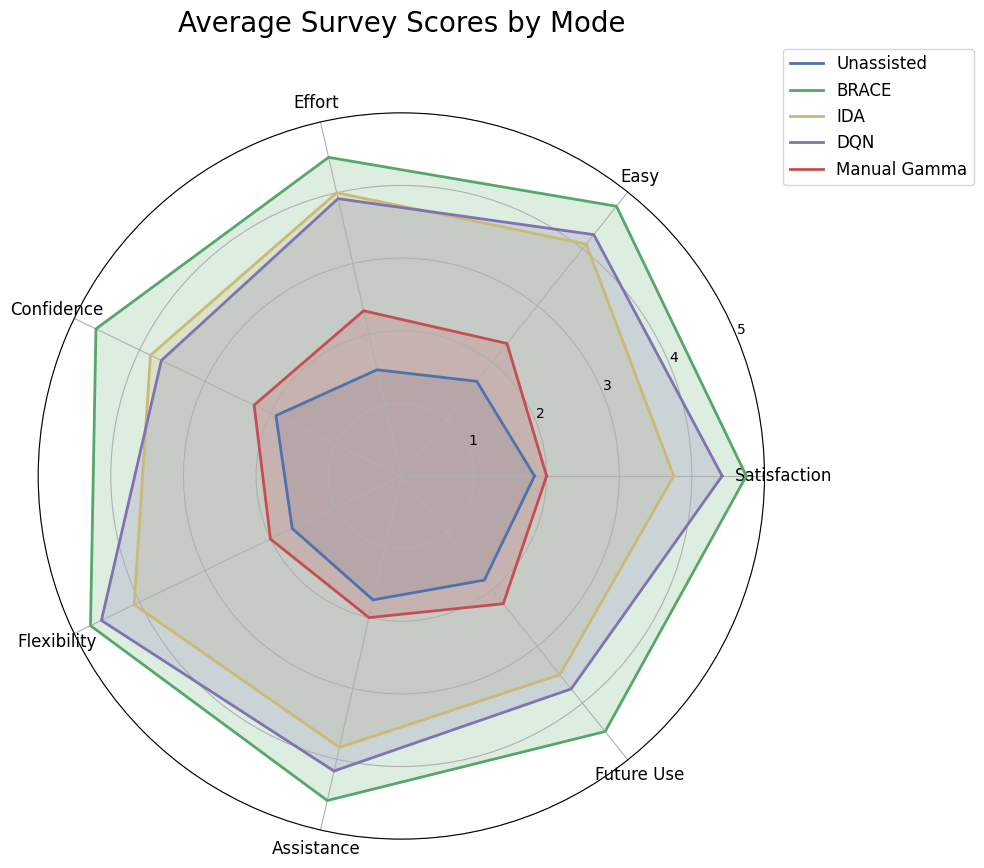


Generating Plot 3: Grouped Bar Plots with Significance...


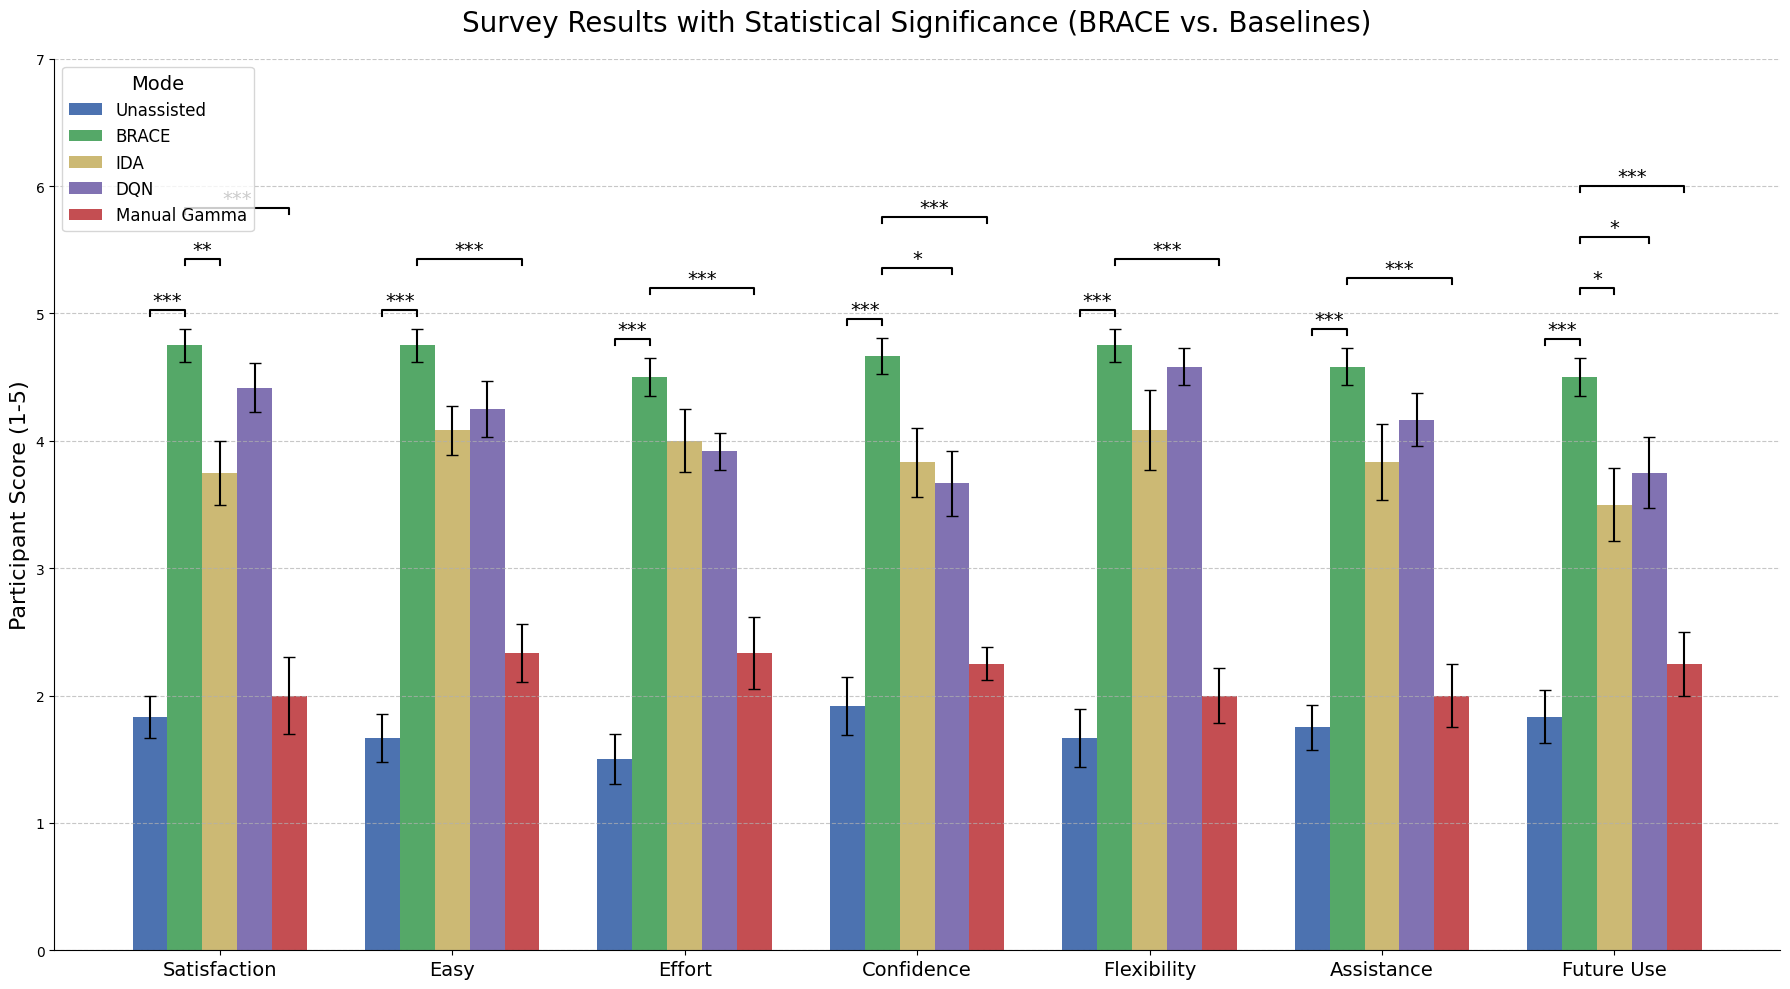

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from math import pi

# ==============================================================================
# PART 1: UNIFIED DATA GENERATION
# This function is called only ONCE to create a consistent dataset.
# ==============================================================================

def generate_consistent_data():
    """
    Generates a single, consistent, and nuanced dataset with clear performance tiers.
    """
    modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
    questions = [
        "Satisfaction", "Easy", "Effort", "Confidence",
        "Flexibility", "Assistance", "Future Use"
    ]
    num_participants = 12
    
    score_profiles = {
        'BRACE':        {'mean': 4.7, 'std': 0.6},
        'DQN':          {'mean': 4.2, 'std': 1.0},
        'IDA':          {'mean': 3.6, 'std': 1.1},
        'Manual Gamma': {'mean': 2.2, 'std': 0.9},
        'Unassisted':   {'mean': 1.6, 'std': 0.7}
    }

    all_data = []
    for mode in modes:
        profile = score_profiles[mode]
        for p_id in range(1, num_participants + 1):
            for q in questions:
                raw_score = np.random.normal(loc=profile['mean'], scale=profile['std'])
                clipped_score = np.clip(raw_score, 1, 5)
                final_score = np.round(clipped_score).astype(int)
                all_data.append([mode, p_id, q, final_score])
                
    return pd.DataFrame(all_data, columns=["Mode", "Participant", "Question", "Score"])

# ==============================================================================
# PART 2: PLOTTING FUNCTIONS
# Each function below takes the same DataFrame 'df' as input.
# ==============================================================================

def plot_faceted_violinplots(df):
    """(PLOT 1) Generates a grid of violin plots using sns.catplot."""
    print("\nGenerating Plot 1: Faceted Violin Plots...")
    modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
    questions = df['Question'].unique()
    palette = {'Unassisted': '#4c72b0', 'BRACE': '#55a868', 'IDA': '#ccb974', 'DQN': '#8172b2', 'Manual Gamma': '#c44e52'}

    g = sns.catplot(
        data=df, x="Mode", y="Score", col="Question", col_wrap=4,
        kind="violin", col_order=questions, order=modes, palette=palette,
        inner="quartile", height=4, aspect=1.2
    )
    g.fig.suptitle("Participant Survey Responses by Mode and Question", y=1.03, fontsize=20)
    g.set_axis_labels("Mode", "Participant Score (1-5)")
    g.set_titles("Question: {col_name}", size=14)
    g.set(ylim=(0, 6))
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


def plot_spider_chart(df):
    """(PLOT 2) Generates a spider chart of the average scores."""
    print("\nGenerating Plot 2: Spider Chart...")
    modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
    questions = df['Question'].unique()
    palette = {'Unassisted': '#4c72b0', 'BRACE': '#55a868', 'IDA': '#ccb974', 'DQN': '#8172b2', 'Manual Gamma': '#c44e52'}

    df_avg = df.groupby(['Mode', 'Question'])['Score'].mean().unstack().loc[modes][questions]
    labels = df_avg.columns.tolist()
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ax.set_ylim(0, 5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=12)

    for mode_name, row in df_avg.iterrows():
        values = row.values.flatten().tolist() + [row.values[0]]
        ax.plot(angles, values, linewidth=2, linestyle="solid", label=mode_name, color=palette[mode_name])
        ax.fill(angles, values, alpha=0.2, color=palette[mode_name])

    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)
    plt.title("Average Survey Scores by Mode", size=20, y=1.1)
    plt.tight_layout()
    plt.show()


def plot_barplots_with_stats(df):
    """(PLOT 3) Creates a grouped bar plot with automated statistical tests."""
    print("\nGenerating Plot 3: Grouped Bar Plots with Significance...")
    modes = ['Unassisted', 'BRACE', 'IDA', 'DQN', 'Manual Gamma']
    questions = df['Question'].unique()
    palette = {'Unassisted': '#4c72b0', 'BRACE': '#55a868', 'IDA': '#ccb974', 'DQN': '#8172b2', 'Manual Gamma': '#c44e52'}
    
    stats_df = df.groupby(['Question', 'Mode'])['Score'].agg(mean='mean', sem=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))).unstack().loc[questions]
    
    significance_data = []
    baselines = [m for m in modes if m != 'BRACE']
    for question in questions:
        brace_scores = df[(df['Mode'] == 'BRACE') & (df['Question'] == question)]['Score'].values
        for baseline_mode in baselines:
            baseline_scores = df[(df['Mode'] == baseline_mode) & (df['Question'] == question)]['Score'].values
            if len(brace_scores) == len(baseline_scores):
                stat, p_value = stats.wilcoxon(brace_scores, baseline_scores)
                if p_value < 0.05:
                    symbol = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
                    significance_data.append((question, baseline_mode, 'BRACE', symbol))

    fig, ax = plt.subplots(figsize=(18, 10))
    bar_width = 0.15
    x = np.arange(len(questions))
    for i, mode in enumerate(modes):
        offset = (i - len(modes) // 2) * bar_width
        ax.bar(x + offset, stats_df[('mean', mode)], width=bar_width, yerr=stats_df[('sem', mode)], label=mode, color=palette[mode], capsize=4)

    bracket_levels = {q: 0 for q in questions}
    for question, mode1, mode2, symbol in significance_data:
        q_idx = list(questions).index(question)
        m1_idx = modes.index(mode1)
        m2_idx = modes.index(mode2)
        x1 = x[q_idx] + (m1_idx - len(modes) // 2) * bar_width
        x2 = x[q_idx] + (m2_idx - len(modes) // 2) * bar_width
        max_bar_height = max(stats_df.loc[question, ('mean', mode1)] + stats_df.loc[question, ('sem', mode1)], stats_df.loc[question, ('mean', mode2)] + stats_df.loc[question, ('sem', mode2)])
        bracket_height = max_bar_height + 0.1 + bracket_levels[question] * 0.4
        bracket_levels[question] += 1
        ax.plot([x1, x1, x2, x2], [bracket_height, bracket_height + 0.05, bracket_height + 0.05, bracket_height], lw=1.5, c='black')
        ax.text((x1 + x2) / 2, bracket_height + 0.05, symbol, ha='center', va='bottom', fontsize=14)

    ax.set_ylabel("Participant Score (1-5)", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(questions, fontsize=14)
    ax.set_ylim(0, 7)
    ax.set_title("Survey Results with Statistical Significance (BRACE vs. Baselines)", fontsize=20, pad=20)
    ax.legend(title='Mode', fontsize=12, title_fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# ==============================================================================
# PART 3: MAIN EXECUTION
# ==============================================================================
if __name__ == '__main__':
    # 1. Generate the master dataset ONCE.
    master_df = generate_consistent_data()
    
    print("--- Master DataFrame Generated ---")
    print(master_df.head())
    
    # 2. Pass the SAME dataset to each plotting function.
    plot_faceted_violinplots(master_df)
    plot_spider_chart(master_df)
    plot_barplots_with_stats(master_df)